# P&S Module 1 - Lesson 1: Data Visualization using Frequency Tables

**Course:** Probability and Statistics (First Semester)

**Week 1:** Lesson 1 (Videos 2 & 3)

**Topics Covered:**
- Frequency Tables
- Pie Charts
- Histograms
- Stem-and-Leaf Plots

---

## Problem Statement

We have collected exam scores from 20 students:

**Scores:** 55, 67, 45, 89, 70, 90, 77, 85, 69, 72, 91, 83, 65, 74, 58, 60, 79, 68, 73, 81

We need to:
1. Create a frequency table
2. Draw a pie chart
3. Plot a histogram
4. Create a stem-and-leaf plot

Let's start with importing the necessary libraries.

In [ ]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

## 1. Frequency Table

A **frequency table** organizes data into intervals (bins) and shows how many values fall into each interval.

For exam scores, we'll use grade ranges:
- 40-50: F grade
- 50-60: D grade
- 60-70: C grade
- 70-80: B grade
- 80-90: A grade
- 90-100: A+ grade

In [ ]:
def draw_numeric_frequency_table(data, bins):
    # Create a pandas Series from the data
    data_series = pd.Series(data)

    # Bin the data into intervals
    intervals = pd.cut(data_series, bins=bins, right=True, include_lowest=True)

    # Frequency count
    frequency = intervals.value_counts(sort=False)

    # Create the frequency table DataFrame
    freq_table = pd.DataFrame({
        'Interval': frequency.index.astype(str),
        'Frequency': frequency.values
    })

    # Add relative and cumulative frequencies
    freq_table['Relative Frequency'] = freq_table['Frequency'] / freq_table['Frequency'].sum()
    freq_table['Cumulative Frequency'] = freq_table['Frequency'].cumsum()

    return freq_table

# Example data - exam scores
scores = [55, 67, 45, 89, 70, 90, 77, 85, 69, 72, 91, 83, 65, 74, 58, 60, 79, 68, 73, 81]

# Define bins (e.g., intervals of 10 points)
bins = [40, 50, 60, 70, 80, 90, 100]

# Generate and print the frequency table
freq_table = draw_numeric_frequency_table(scores, bins)
print(freq_table)

         Interval  Frequency  Relative Frequency  Cumulative Frequency
0  (39.999, 50.0]          1                0.05                     1
1    (50.0, 60.0]          3                0.15                     4
2    (60.0, 70.0]          5                0.25                     9
3    (70.0, 80.0]          5                0.25                    14
4    (80.0, 90.0]          5                0.25                    19
5   (90.0, 100.0]          1                0.05                    20


### 📝 TO DO #1: Change the Data

Try modifying the scores list above with your own data and run the cell again to see how the frequency table changes!

For example, you could:
- Add more scores in the 90-100 range
- Remove some scores from the middle range
- Try a completely different set of 20 scores

## 2. Pie Chart

A **pie chart** shows each category as a slice of a circle. The size of each slice represents the proportion of that category in the whole dataset.

**When to use:** When you want to show parts of a whole as percentages.

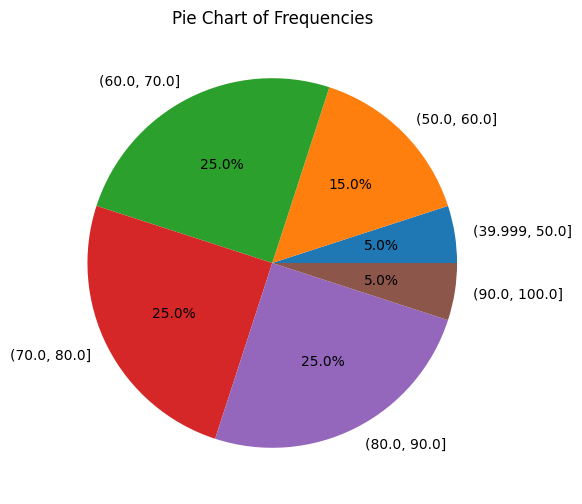

In [ ]:
def plot_pie_chart(freq_table):
    plt.figure(figsize=(6,6))
    plt.pie(freq_table['Frequency'], labels=freq_table['Interval'], autopct='%1.1f%%')
    plt.title('Pie Chart of Frequencies')
    plt.show()

plot_pie_chart(freq_table)

### 📝 TO DO #2: Customize the Pie Chart

Try changing the pie chart by modifying the bins in the frequency table:
- Change `bins = [40, 50, 60, 70, 80, 90, 100]` to `bins = [40, 60, 80, 100]` for larger intervals
- Or try `bins = [40, 55, 70, 85, 100]` for unequal intervals

Go back to the frequency table cell, change the bins, run it, then run the pie chart cell again!

## 3. Histogram

A **histogram** is like a bar chart for numerical data. It shows the distribution of data by grouping values into bins.

**Key difference from bar chart:** The bars touch each other because the data is continuous.

**What to look for:**
- Shape of distribution (symmetric, skewed left, skewed right)
- Where most data is concentrated
- Any gaps or outliers

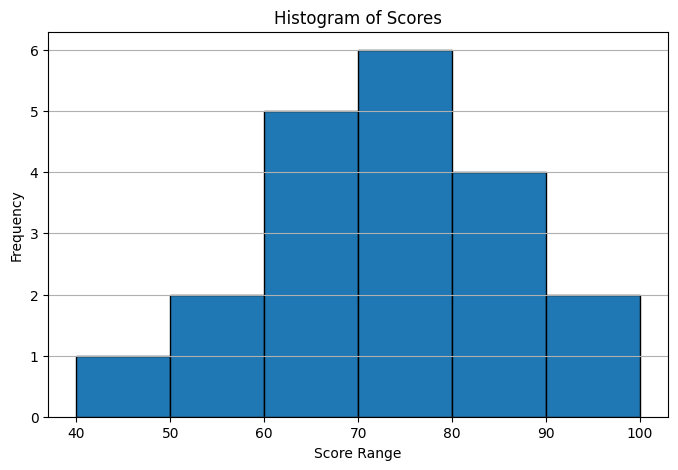

In [ ]:
def plot_histogram(data, bins):
    plt.figure(figsize=(8, 5))
    plt.hist(data, bins=bins, edgecolor='black')
    plt.title('Histogram of Scores')
    plt.xlabel('Score Range')
    plt.ylabel('Frequency')
    plt.grid(axis='y')
    plt.show()

plot_histogram(scores, bins)

### 📝 TO DO #3: Experiment with Bin Sizes

The number of bins affects how we see the distribution. Try different numbers:

Run each line below one at a time to see the difference:

In [ ]:
# TO DO: Uncomment one line at a time and run to see different histograms

# plot_histogram(scores, 5)   # 5 bins - less detail
# plot_histogram(scores, 10)  # 10 bins - medium detail
# plot_histogram(scores, 20)  # 20 bins - more detail (maybe too much!)

## 4. Stem-and-Leaf Plot

A **stem-and-leaf plot** is a way to display data that preserves the actual values while showing the distribution.

**How it works:**
- The "stem" is the tens digit (4, 5, 6, 7, 8, 9)
- The "leaf" is the ones digit (0-9)
- Example: 73 has stem=7 and leaf=3

**Advantage:** You can reconstruct the original data from the plot!

In [ ]:
def stem_and_leaf_plot(data):
    # Sort the data
    data = sorted(data)
    stem_leaf = {}

    for number in data:
        stem = number // 10  # Get tens digit
        leaf = number % 10   # Get ones digit
        if stem in stem_leaf:
            stem_leaf[stem].append(leaf)
        else:
            stem_leaf[stem] = [leaf]

    # Print the plot
    print("Stem | Leaves")
    print("------------")
    for stem, leaves in sorted(stem_leaf.items()):
        leaf_str = ' '.join(str(leaf) for leaf in sorted(leaves))
        print(f" {stem:>2}  | {leaf_str}")

# Example usage
scores = [55, 67, 45, 89, 70, 90, 77, 85, 69, 72,
          91, 83, 65, 74, 58, 60, 79, 68, 73, 81]

stem_and_leaf_plot(scores)

Stem | Leaves
------------
  4  | 5
  5  | 5 8
  6  | 0 5 7 8 9
  7  | 0 2 3 4 7 9
  8  | 1 3 5 9
  9  | 0 1


### Understanding the Stem-and-Leaf Plot

From the plot above:
- Stem 4 | Leaf 5 means score 45
- Stem 6 | Leaves 0 5 7 8 9 means scores 60, 65, 67, 68, 69
- Stem 7 | Leaves 0 2 3 4 7 9 means scores 70, 72, 73, 74, 77, 79

Can you reconstruct all 20 original scores from the plot?

### 📝 TO DO #4: Create Your Own Dataset

Create a stem-and-leaf plot for a different dataset. For example:
- Ages of 15 people in your family
- Daily temperatures for a month
- Test scores from another class

Replace the scores list below with your data:

In [ ]:
# TO DO: Replace this with your own data
my_data = [23, 45, 67, 34, 56, 78, 89, 12, 45, 67, 54, 32, 21, 43, 65]

print("My Custom Stem-and-Leaf Plot:")
stem_and_leaf_plot(my_data)

My Custom Stem-and-Leaf Plot:
Stem | Leaves
------------
  1  | 2
  2  | 1 3
  3  | 2 4
  4  | 3 5 5
  5  | 4 6
  6  | 5 7 7
  7  | 8
  8  | 9


## Summary

### Key Concepts:

1. **Frequency Table**: Groups data into intervals and counts occurrences
2. **Pie Chart**: Shows proportions as slices of a circle
3. **Histogram**: Displays distribution of continuous numerical data
4. **Stem-and-Leaf Plot**: Preserves individual values while showing distribution

### When to Use Each:

- **Frequency Table**: When you need exact counts and cumulative frequencies
- **Pie Chart**: When showing parts of a whole (percentages)
- **Histogram**: When analyzing the shape of a distribution
- **Stem-and-Leaf**: When you have small datasets and want to preserve values

### Practice Questions:

1. Which visualization best shows if the exam scores are normally distributed?
2. From the stem-and-leaf plot, what is the median score?
3. What percentage of students scored 70 or above?
4. If you had 1000 scores instead of 20, which visualization would be least useful?